In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import anndata as ad

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
import pandas as pd
from pyliftover import LiftOver

# 初始化 liftover 对象
lo = LiftOver('hg19', 'hg38')  # 第一次运行会自动下载 chain 文件

# 示例 DataFrame（你可以换成自己的实际数据）
df = pd.DataFrame({
    'chr_100k': ['chr1:0_100000', 'chr2:100000_200000', 'chrY:59000000_59100000']
})

# 定义转换函数
def convert_interval(interval):
    try:
        chrom, pos_range = interval.split(':')
        start_str, end_str = pos_range.split('_')
        start, end = int(start_str), int(end_str)

        # 处理起点为0的特殊情况，改为1尝试转换
        start_to_convert = 1 if start == 0 else start

        res_start = lo.convert_coordinate(chrom, start_to_convert)
        res_end = lo.convert_coordinate(chrom, end - 1)  # 闭区间

        # 处理各种转换失败的情况：
        if not res_start and not res_end:
            # 两者都失败，返回原区间
            return interval
        elif not res_start and res_end:
            # start失败，end成功：start = end转换后 - 100000
            new_chrom = res_end[0][0]
            new_end = res_end[0][1] + 1
            new_start = max(new_end - 100000, 0)
            return f"{new_chrom}:{int(new_start)}_{int(new_end)}"
        elif res_start and not res_end:
            # end失败，start成功：end = start转换后 + 100000
            new_chrom = res_start[0][0]
            new_start = res_start[0][1] - 1 if start == 0 else res_start[0][1]
            new_start = max(new_start, 0)
            new_end = new_start + 100000
            return f"{new_chrom}:{int(new_start)}_{int(new_end)}"
        else:
            # 两者都成功
            new_chrom = res_start[0][0]
            new_start = res_start[0][1] - 1 if start == 0 else res_start[0][1]
            new_start = max(new_start, 0)
            new_end = res_end[0][1] + 1
            return f"{new_chrom}:{int(new_start)}_{int(new_end)}"
    except Exception as e:
        print(f"Error processing interval {interval}: {e}")
        return None

# 应用转换函数到每一行
df['chr_100k_hg38'] = df['chr_100k'].apply(convert_interval)

# 输出结果
print(df)


                 chr_100k           chr_100k_hg38
0           chr1:0_100000           chr1:0_100000
1      chr2:100000_200000      chr2:100000_200000
2  chrY:59000000_59100000  chrY:56853853_56953852


In [3]:
import pandas as pd

# 示例 df
df = pd.DataFrame({
    'colx': ['chr1:0_100000', 'chr2:100000_200000', 'chr17:53000000_53010000', 'chr8:127000000_127010000']
})

# POSITIVE 区间列表
POS_LIST = [
    'chr2:54448152_58624587',
    'chr2:118483904_118488904',
    'chr20:7293703_8236529',
    'chr2:51804053_54073023',
    'chr17:52106827_54486261',
    'chr21:5216245_5255990',
    'chr8:126424717_127997899'
]

# 将 POS_LIST 转换为标准区间列表 (chr, start, end)
def parse_region(region_str):
    chrom, coords = region_str.split(':')
    start_str, end_str = coords.split('_')
    return (chrom, int(start_str), int(end_str))

positive_intervals = [parse_region(pos) for pos in POS_LIST]

# 判断一个区域是否与任意 positive 区域重叠
def has_overlap(region_str):
    chrom, coords = region_str.split(':')
    start, end = map(int, coords.split('_'))

    for pos_chr, pos_start, pos_end in positive_intervals:
        if chrom == pos_chr:
            # 判断是否有重叠（交集）：不是完全左或右就算交集
            if not (end < pos_start or start > pos_end):
                return True
    return False

# 应用判断函数，添加新列
df['is_positive'] = df['colx'].apply(has_overlap)

# 查看结果
print(df)


                       colx  is_positive
0             chr1:0_100000        False
1        chr2:100000_200000        False
2   chr17:53000000_53010000         True
3  chr8:127000000_127010000         True


In [4]:
# 1.下载已报道各细胞系CNV、ECDNA区域数据
# 2.识别两者的fragments，统计数量，剩下的就是BG
# 3.三者分别统计密度分布
# 4.三者统计中位数分布，差异检验

In [5]:
# COLO320DM
# COLO320HSR
# 

In [6]:
import pandas as pd

# 读取 Excel 文件中的 "COLO" sheet
df = pd.read_excel('E:/05.project/04.ecDNA/01.data/scCircle-seq/FIG2.xlsx', sheet_name='Colo320DM', index_col=None)
df

,CHR,POS1,POS2,FREQUENCY,UNIFORMITY,TYPE
0,chr1,6914523,6931099,0.0,0.000000,Low frequency unstable circle(LU)
1,chr1,10387568,10389622,0.0,0.000000,Low frequency unstable circle(LU)
2,chr1,15190708,15190933,0.0,0.000000,Low frequency unstable circle(LU)
3,chr1,25449545,25470425,0.0,0.000000,Low frequency unstable circle(LU)
4,chr1,27724025,27725549,0.0,0.000000,Low frequency unstable circle(LU)
...,...,...,...,...,...,...
6763,chr1,700739,703108,1.0,0.057143,Low frequency unstable circle(LU)
6764,chr1,36461511,36494388,1.0,0.057143,Low frequency unstable circle(LU)
6765,chr19,49487146,49487578,1.0,0.171429,Low frequency unstable circle(LU)
6766,chrY,5538464,5541539,1.0,0.057143,Low frequency unstable circle(LU)


In [7]:
df["region"] = df["CHR"]+":"+(df["POS1"].astype(str))+"_"+(df["POS2"].astype(str))
df

,CHR,POS1,POS2,FREQUENCY,UNIFORMITY,TYPE,region
0,chr1,6914523,6931099,0.0,0.000000,Low frequency unstable circle(LU),chr1:6914523_6931099
1,chr1,10387568,10389622,0.0,0.000000,Low frequency unstable circle(LU),chr1:10387568_10389622
2,chr1,15190708,15190933,0.0,0.000000,Low frequency unstable circle(LU),chr1:15190708_15190933
3,chr1,25449545,25470425,0.0,0.000000,Low frequency unstable circle(LU),chr1:25449545_25470425
4,chr1,27724025,27725549,0.0,0.000000,Low frequency unstable circle(LU),chr1:27724025_27725549
...,...,...,...,...,...,...,...
6763,chr1,700739,703108,1.0,0.057143,Low frequency unstable circle(LU),chr1:700739_703108
6764,chr1,36461511,36494388,1.0,0.057143,Low frequency unstable circle(LU),chr1:36461511_36494388
6765,chr19,49487146,49487578,1.0,0.171429,Low frequency unstable circle(LU),chr19:49487146_49487578
6766,chrY,5538464,5541539,1.0,0.057143,Low frequency unstable circle(LU),chrY:5538464_5541539


In [8]:
ECDNA_LIST = df[df['TYPE'].isin(['High frequency unstable circle(HU)', 'High frequency stable circle(HS)'])]['region'].tolist()
ECDNA_LIST

['chr2:54448152_58624587',
 'chr2:118483904_118488904',
 'chr20:7293703_8236529',
 'chr2:51804053_54073023',
 'chr17:52106827_54486261',
 'chr16:60298920_62551801',
 'chr2:48524077_51549879',
 'chr1:162720243_164454232',
 'chr4:150420437_150959633',
 'chr2:32916631_36183939',
 'chr2:54108569_54340336',
 'chr2:124596441_126200366',
 'chr2:47784052_48426474',
 'chr13:63850254_64953977',
 'chr3:163047115_163621469',
 'chr13:108461996_108794300',
 'chr1:146717333_148015223',
 'chr14:19662916_20249895',
 'chr7:133151477_133423250',
 'chr2:126367614_127046915',
 'chr13:73208815_74541787',
 'chr13:59754128_60265899',
 'chr9:63814504_63899057',
 'chr2:128668296_128861646',
 'chr4:19000301_19226331',
 'chr11:16399105_16736919',
 'chr2:129249377_129686291',
 'chr1:149871482_150549488',
 'chr13:72119279_73058972',
 'chr22:12539889_12641730',
 'chr21:10427096_10651126',
 'chr20:30811898_30914733',
 'chr16:33606930_33656903',
 'chr13:27542546_27980746',
 'chr1:150553400_150718975',
 'chr20:29013259

In [9]:
fname = "COLO320DM_rep6"

In [10]:
cell_cov_path = f"D:/02.project/18.ecDNA/01.result/result_1k/CRC/COLO320DM/GSM4861361_{fname}_atac_fragments.tsv.gz/cell_coverage.matrix.tsv"

In [11]:
df_fragments_cutoff_normalize = pd.read_csv(cell_cov_path,sep="\t",index_col=0)
dfcn_dd = df_fragments_cutoff_normalize.drop_duplicates(subset=['barcode','chr_100k'])
### Transform: 删除chrM
dfcn_dd = Transform(df_fragments=dfcn_dd,Delete_chrM_option=True)
# 应用转换函数到每一行
dfcn_dd['chr_100k_hg38'] = dfcn_dd['chr_100k'].apply(convert_interval)
# 应用判断ECDNA函数，添加新列
dfcn_dd['is_ECDNA'] = dfcn_dd['chr_100k_hg38'].apply(has_overlap)

df_fragments.chrom character content contains chr.


In [12]:
dfcn_dd

,chrom,chromStart,chromEnd,barcode,readSupport,fragLen,start_1k,end_1k,start_100k,end_100k,chr_raw,chr_1k,chr_100k,fragnum_raw,fragnum_100k,Coverage,chr_100k_hg38,is_ECDNA
2,chr1,10097,10272,AGGTCCGGTTACAAAC-1,1,175,10000,11000,0,100000,chr1:10097_10272,chr1:10000_11000,chr1:0_100000,5483,1,1.823819,chr1:0_100000,False
6,chr1,10107,10491,AGCCTCCGTTCACTGT-1,1,384,10000,11000,0,100000,chr1:10107_10491,chr1:10000_11000,chr1:0_100000,8919,1,1.121202,chr1:0_100000,False
9,chr1,10145,10210,TAGCTAATCAATGTGC-1,1,65,10000,11000,0,100000,chr1:10145_10210,chr1:10000_11000,chr1:0_100000,69626,1,0.143625,chr1:0_100000,False
16,chr1,10169,10333,AGGTAACCATTGCGAC-1,1,164,10000,11000,0,100000,chr1:10169_10333,chr1:10000_11000,chr1:0_100000,22615,2,0.884369,chr1:0_100000,False
23,chr1,10222,10560,CTCCAAACAAGGAATC-1,1,338,10000,11000,0,100000,chr1:10222_10560,chr1:10000_11000,chr1:0_100000,6451,1,1.550147,chr1:0_100000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126962056,chrY,59031358,59031905,TCCTCTAAGTTCCTCA-1,1,547,59031000,59032000,59000000,59100000,chrY:59031358_59031905,chrY:59031000_59032000,chrY:59000000_59100000,32095,1,0.311575,chrY:56853853_56953852,False
126962064,chrY,59031684,59031893,AGAGATTAGGCGCATC-1,1,209,59031000,59032000,59000000,59100000,chrY:59031684_59031893,chrY:59031000_59032000,chrY:59000000_59100000,8206,1,1.218621,chrY:56853853_56953852,False
126962115,chrY,59032144,59032206,AAACATGCACTGACTA-1,1,62,59032000,59033000,59000000,59100000,chrY:59032144_59032206,chrY:59032000_59033000,chrY:59000000_59100000,8609,1,1.161575,chrY:56853853_56953852,False
126962134,chrY,59032609,59032906,ATTGCAGGTCAATACG-1,1,297,59032000,59033000,59000000,59100000,chrY:59032609_59032906,chrY:59032000_59033000,chrY:59000000_59100000,5901,1,1.694628,chrY:56853853_56953852,False


In [13]:
dfcn_dd['Group'] = dfcn_dd['is_ECDNA'].map({False: 'Background', True: 'ecDNA'})
df_tmp = dfcn_dd.drop_duplicates(subset=['chr_100k_hg38','Group'])
df_tmp["Group"].value_counts()

Background    28395
ecDNA           121
Name: Group, dtype: int64

t-test p-value: 0.000e+00


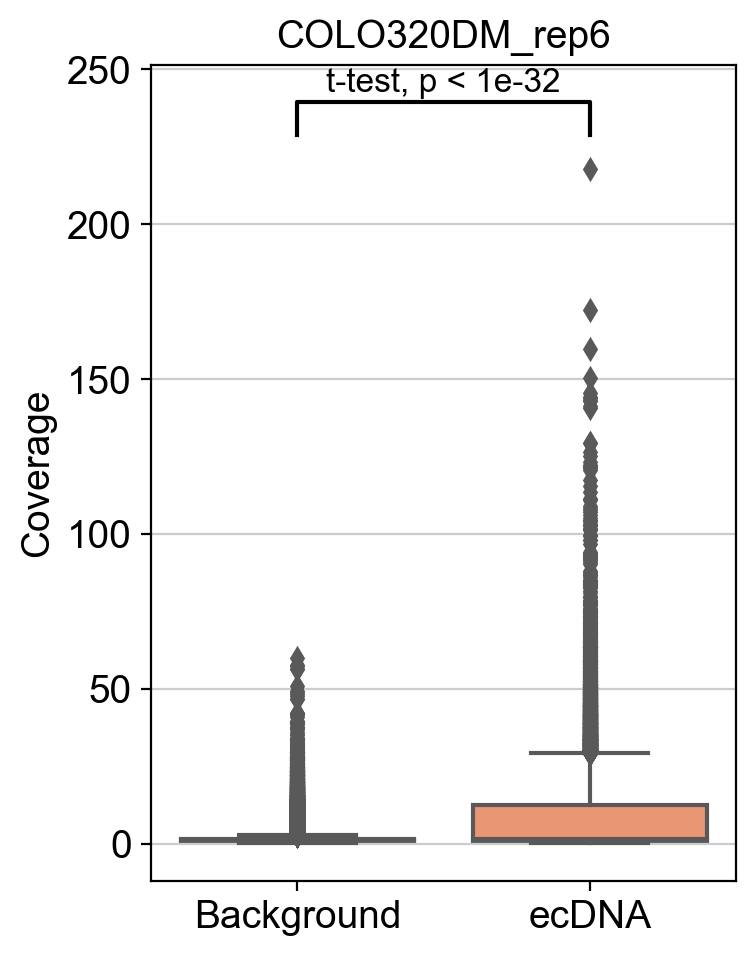

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 替换为你的真实数据
# dfcn_dd = pd.read_csv('your_data.tsv', sep='\t')

# 显式复制以避免修改原数据
plot_df = dfcn_dd.copy()
plot_df['Group'] = plot_df['is_ECDNA'].map({False: 'Background', True: 'ecDNA'})

# 分组
group_true = plot_df[plot_df['Group'] == 'ecDNA']['Coverage']
group_false = plot_df[plot_df['Group'] == 'Background']['Coverage']

# t检验
t_stat, p_val = ttest_ind(group_true, group_false, equal_var=False)

# 打印 p 值
print(f"t-test p-value: {p_val:.3e}")

# 绘图
plt.figure(figsize=(4, 5))
sns.boxplot(data=plot_df, x='Group', y='Coverage', palette="Set2")

# 添加 p 值标注
x1, x2 = 0, 1
y = plot_df['Coverage'].max() * 1.05
h = plot_df['Coverage'].max() * 0.05
plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='k')

# p 值文本内容
if p_val == 0.0:
    p_text = "t-test, p < 1e-32"
else:
    p_text = f"t-test, p = {p_val:.2e}"

plt.text((x1 + x2) * 0.5, y + h * 1.1, p_text, ha='center', va='bottom', fontsize=12)

# 标签与标题
plt.xlabel("")  # 如果不需要横轴标题
plt.ylabel("Coverage")
plt.title(f"{fname}")
plt.tight_layout()
#plt.show()
plt.savefig(f"D:/02.project/18.ecDNA/02.code/v0.1.1/Fig-s1-a_ECDNA_CNV_BG/f01-t-test_{fname}.pdf", bbox_inches='tight')

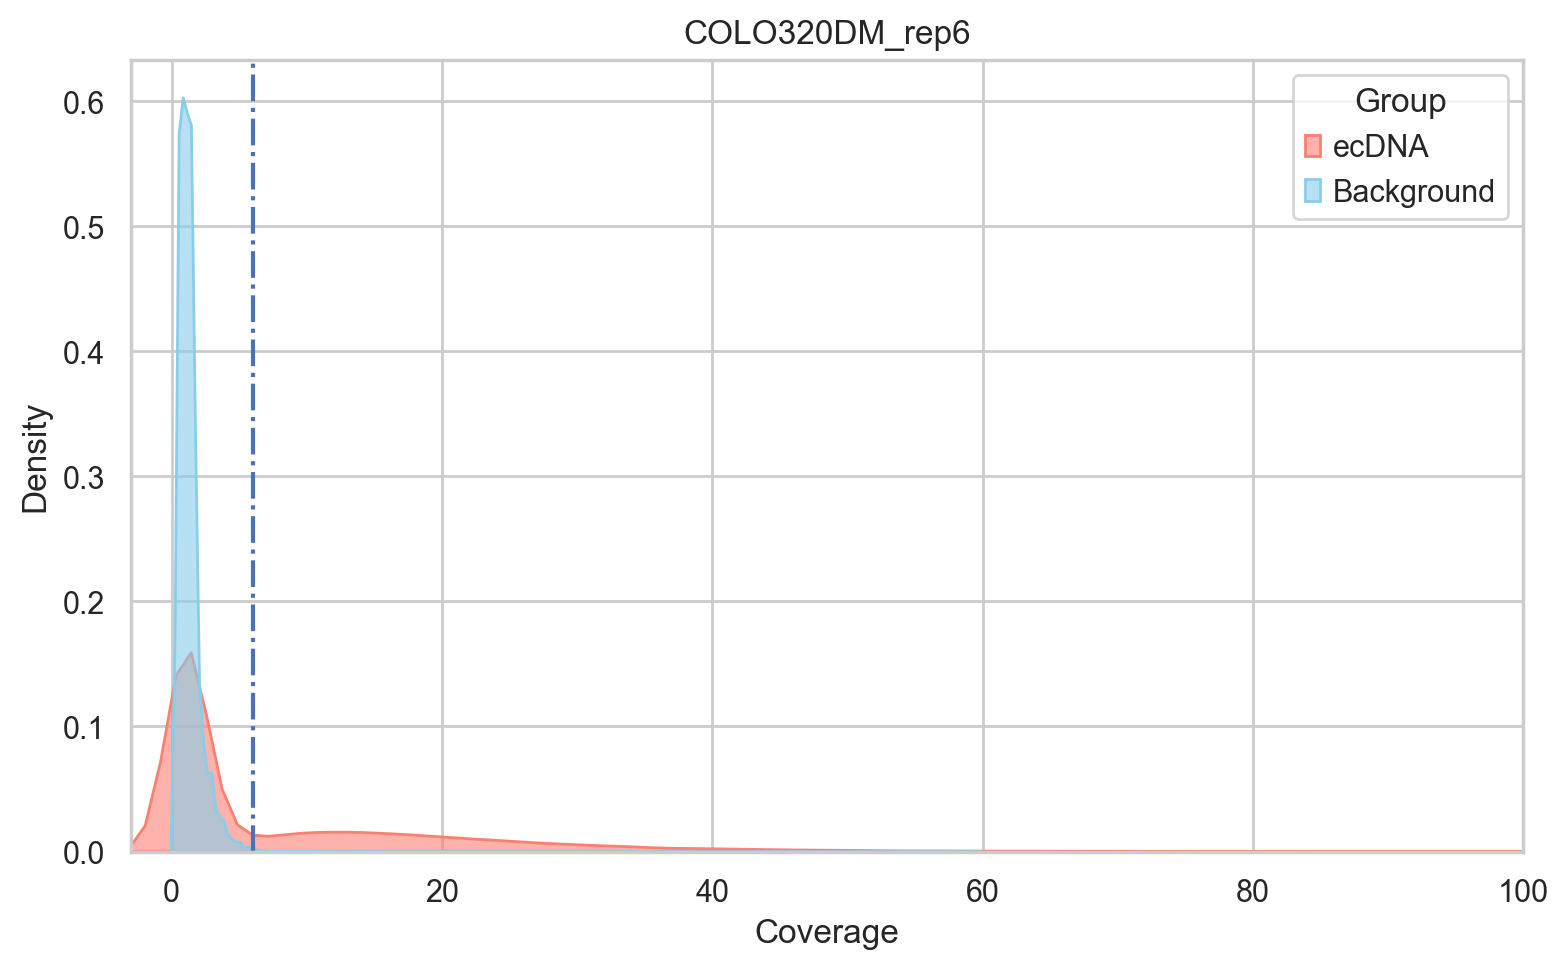

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你已有 dfcn_dd，其中 'is_ECDNA' 是布尔型，'Coverage' 是数值型
# 设置图形风格
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

# 绘制 TRUE 组密度曲线
sns.kdeplot(
    data=dfcn_dd[dfcn_dd['is_ECDNA'] == True],
    x="Coverage",
    fill=True,
    label='ecDNA',
    color='salmon',
    alpha=0.6
)

# 绘制 FALSE 组密度曲线
sns.kdeplot(
    data=dfcn_dd[dfcn_dd['is_ECDNA'] == False],
    x="Coverage",
    fill=True,
    label='Background',
    color='skyblue',
    alpha=0.6
)

plt.axvline(6, color = "b", linestyle = "-.")
plt.xlim(-3, 100)

# 添加图例和标题
plt.legend(title="Group")
plt.title(f"{fname}")
plt.xlabel("Coverage")
plt.ylabel("Density")
plt.tight_layout()
#plt.show()
plt.savefig(f"D:/02.project/18.ecDNA/02.code/v0.1.1/Fig-s1-a_ECDNA_CNV_BG/f02-density_{fname}.pdf", bbox_inches='tight')

In [ ]:
fragments_path = "E:/05.project/04.ecDNA/01.data/CRC/GSM4861353_COLO320DM_rep2_atac_fragments.tsv.gz"
df_fragments = read_bgi_as_dataframe(path=fragments_path)

### Transform: 删除chrM
df_fragments = Transform(df_fragments=df_fragments,Delete_chrM_option=True)

### segmentation 片段分割:
df_fragments_cutoff_segmentation = fragments_segmentation(df_fragments=df_fragments)

### Normalize(计算覆盖度Coverage)：
#单线程
df_fragments_cutoff_normalize = df_fragments_cutoff_segmentation.groupby(df_fragments_cutoff_segmentation["barcode"]).apply(Normalize)

### v3：：较于前版本v2，加入（合并）了:：cell_coverage.py 步骤 
df_fragments_cutoff_normalize_dd = df_fragments_cutoff_normalize.drop_duplicates(subset=['barcode','chr_100k'])
df_fragments_cutoff_normalize_dd.to_csv("./Fig-s1-a_ECDNA_CNV_BG/cell_coverage.matrix.tsv",sep="\t",index=True)